[[2.79000000e+01 1.68849240e+04]
 [3.37700000e+01 1.72555230e+03]
 [3.30000000e+01 4.44946200e+03]
 ...
 [3.68500000e+01 1.62983350e+03]
 [2.58000000e+01 2.00794500e+03]
 [2.90700000e+01 2.91413603e+04]]


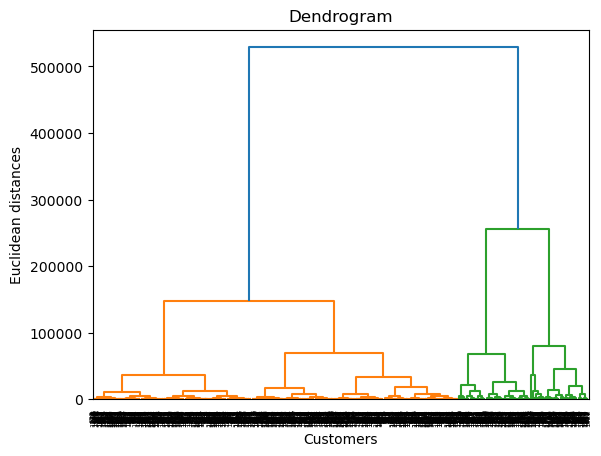

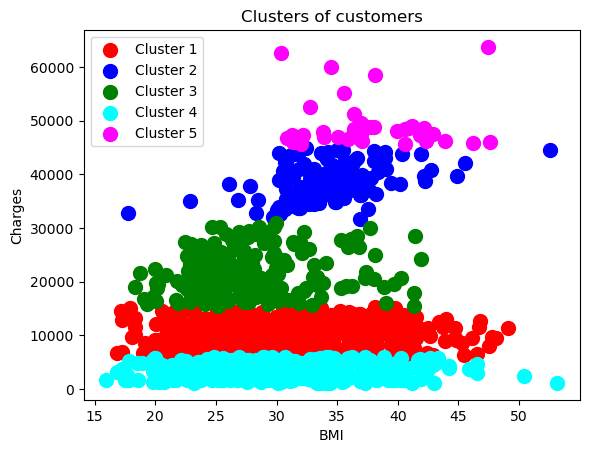

In [23]:
# Importing the libraries 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

#Importing the dataset 
dataset = pd.read_csv('insurance.csv') 
from sklearn.preprocessing import LabelEncoder
X = dataset.iloc[:, [2, 6]].values
le = LabelEncoder()
print(X) 

#Using the dendrogram to find the optimal number of clusters 
import scipy.cluster.hierarchy as sch 
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward')) 
plt.title('Dendrogram') 
plt.xlabel('Customers') 
plt.ylabel('Euclidean distances') 
plt.show() 

#Training the Hierarchical Clustering model on the dataset 
from sklearn.cluster import AgglomerativeClustering 
# Changed 'affinity' to 'metric' to match current scikit-learn API
hc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage = 'ward') 
y_hc = hc.fit_predict(X) 

#Visualise the Cluster 
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1') 
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Cluster 2') 
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3') 
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4') 
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5') 
plt.title('Clusters of customers') 
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend() 
plt.show()

[[2.79000000e+01 1.68849240e+04]
 [3.37700000e+01 1.72555230e+03]
 [3.30000000e+01 4.44946200e+03]
 ...
 [3.68500000e+01 1.62983350e+03]
 [2.58000000e+01 2.00794500e+03]
 [2.90700000e+01 2.91413603e+04]]


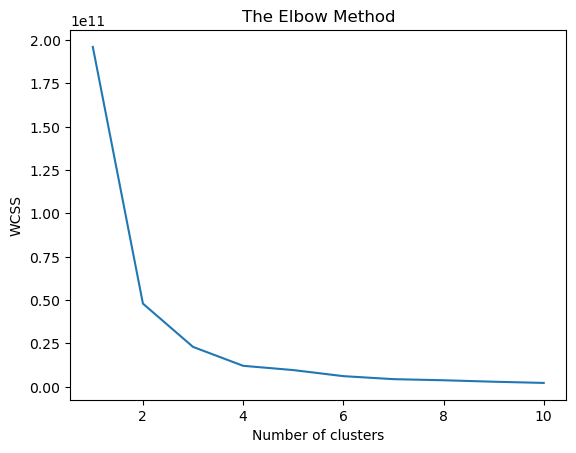

[4 3 3 ... 3 3 2]


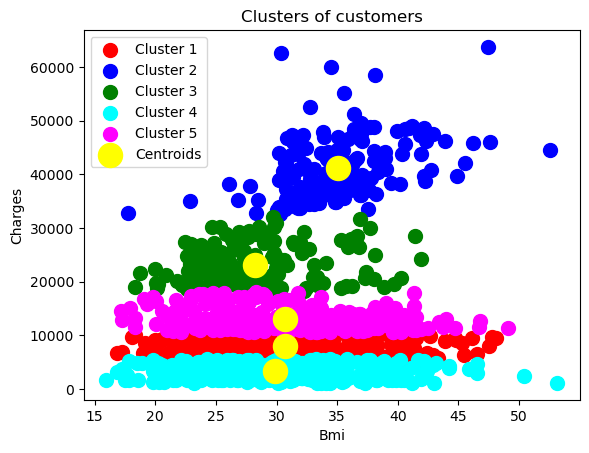

In [21]:
# Importing the libraries 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

#Importing the dataset 
dataset = pd.read_csv('insurance.csv') 
from sklearn.preprocessing import LabelEncoder
X = dataset.iloc[:, [2, 6]].values
le = LabelEncoder()
print(X) 

#Using the elbow method to find the optimal number of clusters 
from sklearn.cluster import KMeans 
wcss = []
for i in range(1, 11): 
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) 
    kmeans.fit(X) 
    wcss.append(kmeans.inertia_) 
plt.plot(range(1, 11), wcss) 
plt.title('The Elbow Method') 
plt.xlabel('Number of clusters') 
plt.ylabel('WCSS') 
plt.show() 
#Apply the K-means model on the Training set 
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42) 
y_kmeans = kmeans.fit_predict(X) 
print(y_kmeans) 

#Visualise the Cluster 
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1') 
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2') 
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3') 
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4') 
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5') 
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids') 
plt.title('Clusters of customers') 
plt.xlabel('Bmi') 
plt.ylabel('Charges') 
plt.legend() 
plt.show() 

In [11]:
#Importing the libraries 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

#Importing the dataset
dataset = pd.read_csv('insurance.csv')
X = dataset[['age', 'sex', 'bmi', 'children', 'region', 'charges']].values
y = dataset.iloc[:, 4].values 

#Encode the categorical dependent variables 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 1] = le.fit_transform(X[:, 1])  
X[:, 4] = le.fit_transform(X[:, 4])  
y = le.fit_transform(y)  

#Splitting the dataset into the Training set and Test set 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#Logistic Regession
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
lr = LogisticRegression(random_state=0, max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Logistic Regression")
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Accuracy")
print(accuracy_score(y_test, y_pred))
print()


# kn model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("KNN")
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Accuracy")
print(accuracy_score(y_test, y_pred))
print()


#naive bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
print("Naive Bayes")
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Accuracy")
print(accuracy_score(y_test, y_pred))
print()

#decision tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print("Decision Tree")
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Accuracy")
print(accuracy_score(y_test, y_pred))




Logistic Regression
Confusion Matrix
[[255   9]
 [  4  67]]
Accuracy
0.9611940298507463

KNN
Confusion Matrix
[[256   8]
 [  5  66]]
Accuracy
0.9611940298507463

Naive Bayes
Confusion Matrix
[[255   9]
 [ 18  53]]
Accuracy
0.9194029850746268

Decision Tree
Confusion Matrix
[[257   7]
 [ 10  61]]
Accuracy
0.9492537313432836


In [13]:
print(dataset['smoker'].value_counts())

charges
1639.56310     2
16884.92400    1
29330.98315    1
2221.56445     1
19798.05455    1
              ..
7345.08400     1
26109.32905    1
28287.89766    1
1149.39590     1
29141.36030    1
Name: count, Length: 1337, dtype: int64


Comparison of Regression Models:
                              Model           MSE   R2
0                 Linear Regression  5.143408e-24  1.0
1  Polynomial Regression (Degree 2)  5.396444e-18  1.0
2                  Ridge Regression  7.899944e-08  1.0
3                  Lasso Regression  7.940812e-03  1.0
4            Elastic Net Regression  3.139694e-03  1.0

Best-Fit Model: Linear Regression
R-squared: 1.0
Mean Squared Error: 5.143407534664274e-24

Regression Equation for Linear Regression:
y = 0.00 + (0.10)*age + (0.30)*bmi + (0.30)*children + (0.30)*charges 


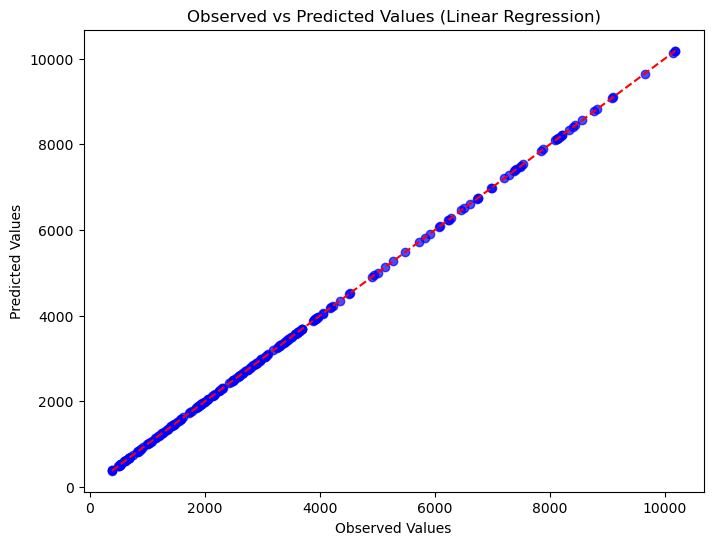

In [15]:
# Importing libraries 

import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  

from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet  
from sklearn.preprocessing import PolynomialFeatures  
from sklearn.metrics import mean_squared_error, r2_score 

# The dataset (insurance.csv)is loaded using pandas 
file_path = 'insurance.csv'   
data = pd.read_csv(file_path) 

# Relevant columns (age, bmi, children, charges) are extracted for analysis  
filtered_data = data[['age', 'bmi', 'children', 'charges']].copy()  

# Handle Missing Values  
filtered_data = filtered_data.fillna(filtered_data.mean())  

# Create target variable 
filtered_data['Total'] = (
    0.1 * filtered_data['age'] +
    0.3 * filtered_data['bmi'] +
    0.3 * filtered_data['children'] +
    0.3 * filtered_data['charges']
) 

# Outlier Detection 
def detect_outliers(data, column):  
    Q1 = data[column].quantile(0.25)  
    Q3 = data[column].quantile(0.75)  
    IQR = Q3 - Q1  
    lower_bound = Q1 - 1.5 * IQR  
    upper_bound = Q3 + 1.5 * IQR  
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]  

# for all columns 
outliers_list = []  

for col in ['age', 'bmi', 'children', 'charges']:  
    outliers_list.append(detect_outliers(filtered_data, col))  

# combine outliers 
outliers = pd.concat(outliers_list).drop_duplicates()  

# Remove Outliers 
filtered_data_no_outliers = filtered_data[~filtered_data.index.isin(outliers.index)]  

# Splitting the Data independent variables (X) 
X = filtered_data_no_outliers[['age', 'bmi', 'children', 'charges']] 

# Splitting the Data target variable (y) 
y = filtered_data_no_outliers['Total']  

# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)  

# Regression models  
models = {  
    "Linear Regression": LinearRegression(),  
    "Polynomial Regression (Degree 2)": LinearRegression(),  
    "Ridge Regression": Ridge(alpha=1.0),  
    "Lasso Regression": Lasso(alpha=0.1),  
    "Elastic Net Regression": ElasticNet(alpha=0.1, l1_ratio=0.5)  
}  

# Polynomial Features 
poly_features = PolynomialFeatures(degree=2)  
X_poly_train = poly_features.fit_transform(X_train)  
X_poly_test = poly_features.transform(X_test)  

# Results storage  
results = []  
predicted_values = {}  

# Prediction  
for name, model in models.items():  

    if "Polynomial" in name:  
        model.fit(X_poly_train, y_train)  
        y_pred = model.predict(X_poly_test)  
    else:  
        model.fit(X_train, y_train)  
        y_pred = model.predict(X_test)  

    # Evaluation metrics – Mean squared error  
    mse = mean_squared_error(y_test, y_pred)  

    # Evaluation metrics – R squared  
    r2 = r2_score(y_test, y_pred)  

    results.append({"Model": name, "MSE": mse, "R2": r2})  
    predicted_values[name] = y_pred  

# Comparison table 
comparison_results = pd.DataFrame(results)  

# Best fit model  
best_model_name = comparison_results.loc[comparison_results['R2'].idxmax(), 'Model'] 
best_model_r2 = comparison_results.loc[comparison_results['R2'].idxmax(), 'R2'] 
best_model_mse = comparison_results.loc[comparison_results['R2'].idxmax(), 'MSE']  

print("Comparison of Regression Models:") 
print(comparison_results) 

print(f"\nBest-Fit Model: {best_model_name}") 
print(f"R-squared: {best_model_r2}") 
print(f"Mean Squared Error: {best_model_mse}")  

# Polynomial regression  
if best_model_name == "Polynomial Regression (Degree 2)":  

    coefficients = models["Polynomial Regression (Degree 2)"].coef_  
    intercept = models["Polynomial Regression (Degree 2)"].intercept_  
    feature_names = poly_features.get_feature_names_out(X.columns)  

    print("\nPolynomial Regression Equation (Degree 2):")  

    equation = f"y = {intercept:.2f} "  

    for coef, feature in zip(coefficients, feature_names):  
        equation += f"+ ({coef:.2f})*{feature} "  

    print(equation)  

# Other models  
else:  

    best_model = models[best_model_name]  
    intercept = best_model.intercept_  
    coefficients = best_model.coef_  

    print(f"\nRegression Equation for {best_model_name}:")  

    equation = f"y = {intercept:.2f} "  

    for coef, feature in zip(coefficients, X.columns):  
        equation += f"+ ({coef:.2f})*{feature} "  

    print(equation)  

# Observed vs Predicted 
plt.figure(figsize=(8, 6))  
plt.scatter(y_test, predicted_values[best_model_name], alpha=0.7, color="blue")  
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")  
plt.title(f"Observed vs Predicted Values ({best_model_name})")  
plt.xlabel("Observed Values")  
plt.ylabel("Predicted Values")  
plt.show()